# Manage results

This notebook will interpret the results from different maintenance rewards


In [60]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [61]:
# Configuration
results_dir_root = Path('../../simulation_results')  # For TD_test_instance files

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)



if results_dir_root.exists():
    hourly_files_root = list(results_dir_root.glob('*TD_0612251255*_hourly_seed_*.csv'))
    print(f"Found {len(hourly_files_root)} TD_test_instance hourly CSV files")
    for f in hourly_files_root[:5]:
        print(f"  {f.name}")

Found 3 TD_test_instance hourly CSV files
  sjovik_sund_alphas_TD_0612251255_0.300_results_hourly_seed_1.csv
  sjovik_sund_alphas_TD_0612251255_0.400_results_hourly_seed_1.csv
  sjovik_sund_alphas_TD_0612251255_0.500_results_hourly_seed_1.csv


## Helper functions

1) Extract alphas from file name
2) Wrap hour to display
3) Format time

In [62]:


# -------------------------------------------------------------------
# 1. Helper functions
# -------------------------------------------------------------------

def extract_alpha_from_filename(filename):
  
    # 1) Most robust: number directly before `_results_hourly`
    #    Works for: alphas_TD_0612251255_0.300_results_hourly_seed_1.csv
    match = re.search(r'_([\d]+\.[\d]+)_results_hourly', filename)
    if match:
        return float(match.group(1))

    # 2) Original pattern: alphas_run..._0.001
    match = re.search(r'alphas_run.*?_([\d\.]+)', filename)
    if match:
        return float(match.group(1))

    # 3) Fallback: alpha_0.01, alphaX_0.01 etc.
    match = re.search(r'alpha[a-z0-9_]*_([\d\.]+)', filename)
    if match:
        return float(match.group(1))

    return None


def wrap_hour_to_display(hour):
    """
    Maps hours 7-30 to display hours 7-6 (07:00 to 06:00 next day).
    Hours 7-24 stay as is, hours 25-30 map to 1-6.
    Returns a tuple: (display_hour, sort_key) where sort_key ensures correct ordering
    """
    if 7 <= hour <= 24:
        return hour, hour          # Hours 7-24
    elif 25 <= hour <= 30:
        return hour - 24, hour     # Hours 25-30 -> 1-6
    else:
        return None, hour          # Filtered out later

def format_hour(h):
    return 0 if h == 24 else h


## Load CSV and process

In [67]:
# -------------------------------------------------------------------
# 3. Load and process each CSV (with your columns)
# -------------------------------------------------------------------

all_hourly_data = []

for file_path in hourly_files_root:
    alpha = extract_alpha_from_filename(file_path.name)
    if alpha is None:
        print(f"Warning: Could not extract alpha from {file_path.name}")
        continue

    try:
        df = pd.read_csv(file_path)

        # Add alpha column from filename
        df["alpha"] = alpha

        # Keep only hours 7–30 (07:00 to 06:00 next day)
        df = df[(df["Hour"] >= 7) & (df["Hour"] <= 30)].copy()

        if len(df) > 0:
            # Map hours to display format (7–24 stay, 25–30 -> 1–6)
            hour_mapping = df["Hour"].apply(wrap_hour_to_display)
            df["Display_Hour"] = hour_mapping.apply(lambda x: x[0])
            df["Sort_Key"] = hour_mapping.apply(lambda x: x[1])

            # Remove rows that couldn't be mapped (outside 7–30)
            df = df[df["Display_Hour"].notna()].copy()
            
            violation_cols = [
                "Starvations",
                "Long Congestions",
                #"Maintenance Violations",
                "Maintenance Starvations",
            ]
            # metrics we usually want to sum as well
            sum_also = [
                "Bike Pickups",
                "Bike Deliveries",
                "Maintenance Time (minutes)",
            ]

            available_violation_cols = [c for c in violation_cols if c in df.columns]
            available_sum_cols = [c for c in sum_also if c in df.columns]

            group_cols = ["Seed", "Day", "Display_Hour"]

            agg_dict = {col: "sum" for col in available_violation_cols + available_sum_cols}
            # 'Sort_Key' for ordering within (Seed, Day)
            agg_dict["Sort_Key"] = "min"

            # Any remaining non-grouping columns -> take first
            for col in df.columns:
                if col in group_cols + list(agg_dict.keys()) + ["Hour"]:
                    continue
                agg_dict.setdefault(col, "first")

            df = df.groupby(group_cols, as_index=False).agg(agg_dict)
            df = df.sort_values(["Seed", "Day", "Sort_Key"])

            # Rename Display_Hour back to Hour for consistency
            df["Hour"] = df["Display_Hour"]
            df = df.drop(["Display_Hour", "Sort_Key"], axis=1)

        all_hourly_data.append(df)
        print(f"Loaded {file_path.name}: {len(df)} rows after processing, alpha={alpha}")

    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

Loaded sjovik_sund_alphas_TD_0612251255_0.300_results_hourly_seed_1.csv: 37 rows after processing, alpha=0.3
Loaded sjovik_sund_alphas_TD_0612251255_0.400_results_hourly_seed_1.csv: 37 rows after processing, alpha=0.4
Loaded sjovik_sund_alphas_TD_0612251255_0.500_results_hourly_seed_1.csv: 37 rows after processing, alpha=0.5


In [64]:
# -------------------------------------------------------------------
# 4. Combine and run diagnostics
# -------------------------------------------------------------------

if all_hourly_data:
    combined_df = pd.concat(all_hourly_data, ignore_index=True)
    print(f"\nTotal data points: {len(combined_df)}")
    print(f"Unique alpha values: {sorted(combined_df['alpha'].unique())}")

    #print("\nColumns:", list(combined_df.columns))
    #print("\nFirst few rows:")
    #print(combined_df.head())

    # Aggregate by alpha across all seeds, days, and hours
    alpha_summary = combined_df.groupby("alpha").agg(
        {
            "Maintenance Time (minutes)": "sum",
            "Maintenance Violations": "sum",
            "Maintenance Starvations": "sum",
            "Starvations": "sum",
            "Bike Pickups": "sum",
            "Bike Deliveries": "sum",
        }
    ).reset_index()

    alpha_summary = alpha_summary.sort_values("alpha")
    print("\nAggregated by Alpha (sum across all seeds, days, and hours):")
    print(alpha_summary.to_string(index=False))


else:
    print("No hourly data found!")

unique_alphas = sorted(combined_df['alpha'].unique())


Total data points: 111
Unique alpha values: [np.float64(0.3), np.float64(0.4), np.float64(0.5)]

Aggregated by Alpha (sum across all seeds, days, and hours):
 alpha  Maintenance Time (minutes)  Maintenance Violations  Maintenance Starvations  Starvations  Bike Pickups  Bike Deliveries
   0.3                      857.97                     285                      466          578           418              414
   0.4                     1544.77                     272                      375          530            54               42
   0.5                     1598.03                     202                      401          666            32               14


Saved combined plot: ..\..\simulation_results\hourly_violation_plots\all_alphas_hourly_violations.png


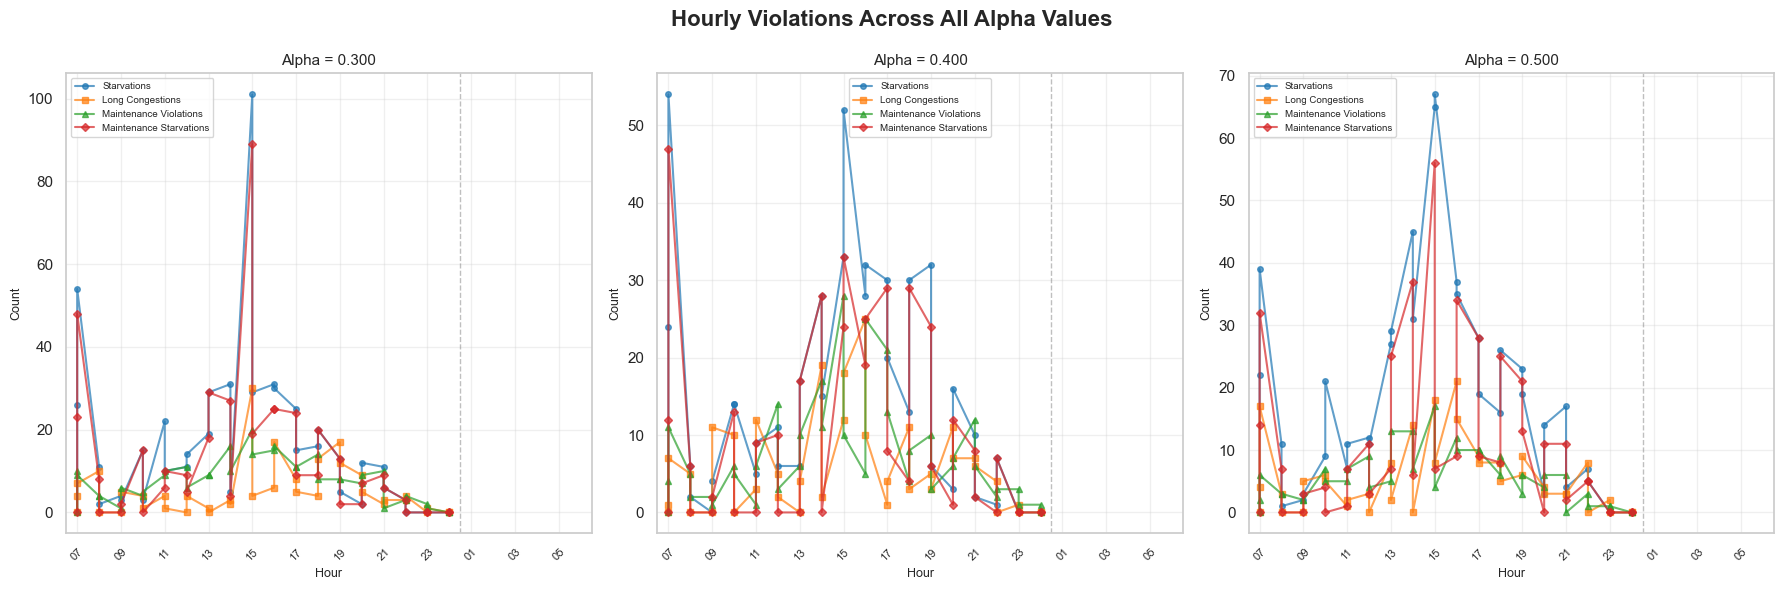

In [65]:
# Optional: Create a summary plot showing all alphas in subplots

n_alphas = len(unique_alphas)
n_cols = 3
n_rows = (n_alphas + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Hourly Violations Across All Alpha Values', fontsize=16, fontweight='bold')

# Flatten axes array if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
markers = ['o', 's', '^', 'D', 'v']

for idx, alpha in enumerate(unique_alphas):
    ax = axes[idx]
    
    # Filter data for this alpha
    alpha_data = combined_df[combined_df['alpha'] == alpha].copy()
    
    # Create hour sequence for plotting: 7, 8, ..., 24, 1, 2, ..., 6
    hour_sequence = list(range(7, 25)) + list(range(1, 7))
    hour_mapping = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    
    # Create a sorted dataframe with hours in display order
    alpha_data_sorted = alpha_data.copy()
    alpha_data_sorted['Plot_Order'] = alpha_data_sorted['Hour'].map(hour_mapping)
    alpha_data_sorted = alpha_data_sorted.sort_values('Plot_Order')
    
    # Plot each violation type
    for i, violation_type in enumerate(violation_cols):
        if violation_type in alpha_data_sorted.columns:
            ax.plot(
                alpha_data_sorted['Plot_Order'],
                alpha_data_sorted[violation_type],
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                label=violation_type,
                linewidth=1.5,
                markersize=4,
                alpha=0.7
            )
    
    ax.set_title(f'Alpha = {alpha:.3f}', fontsize=11)
    ax.set_xlabel('Hour', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show hours 7-24, then 1-6
    hour_labels = [f"{h:02d}" for h in hour_sequence]
    # Map hours to plot positions: 7->7, 8->8, ..., 24->24, 1->25, 2->26, ..., 6->30
    hour_to_position = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    positions = [hour_to_position[h] for h in hour_sequence]
    
    ax.set_xlim(left=6.5, right=30.5)
    ax.set_xticks(positions[::2])  # Show every other hour to avoid crowding
    ax.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), 2)], rotation=45, fontsize=8)
    ax.axvline(x=24.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Hide unused subplots
for idx in range(len(unique_alphas), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save the combined plot
output_dir = results_dir_root / 'hourly_violation_plots'
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / 'all_alphas_hourly_violations.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Saved combined plot: {output_file}")

plt.show()


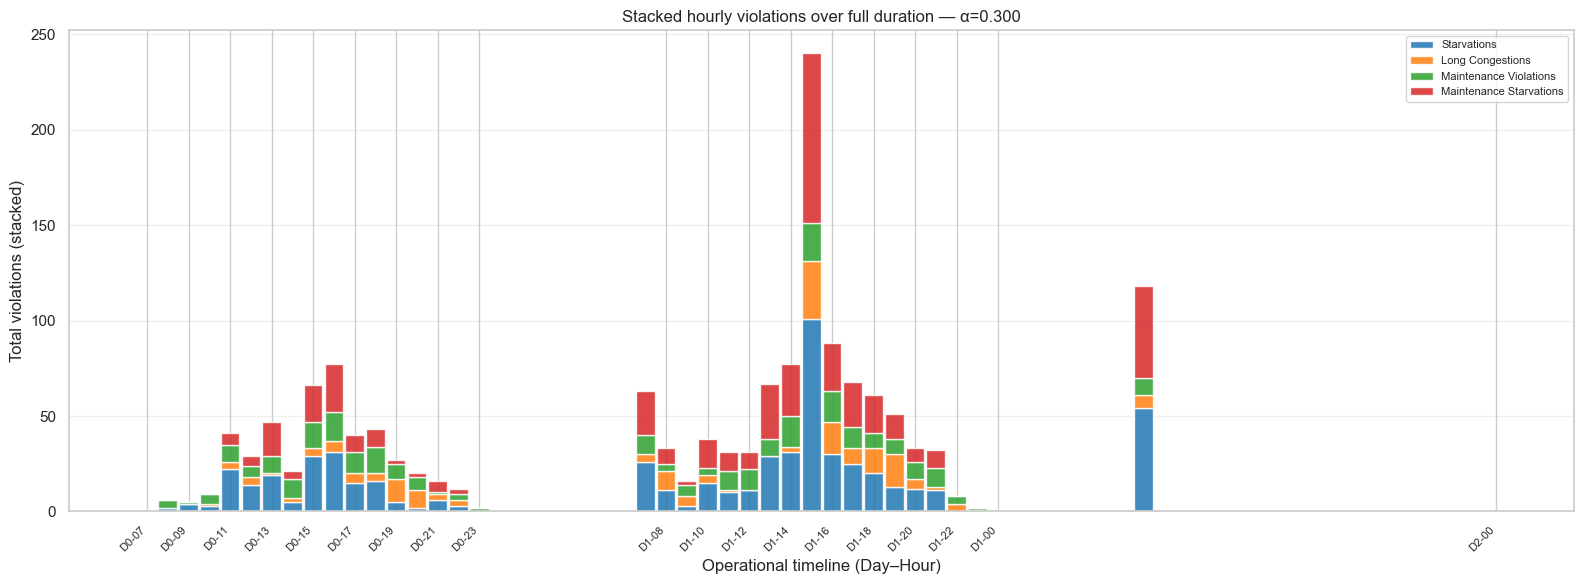

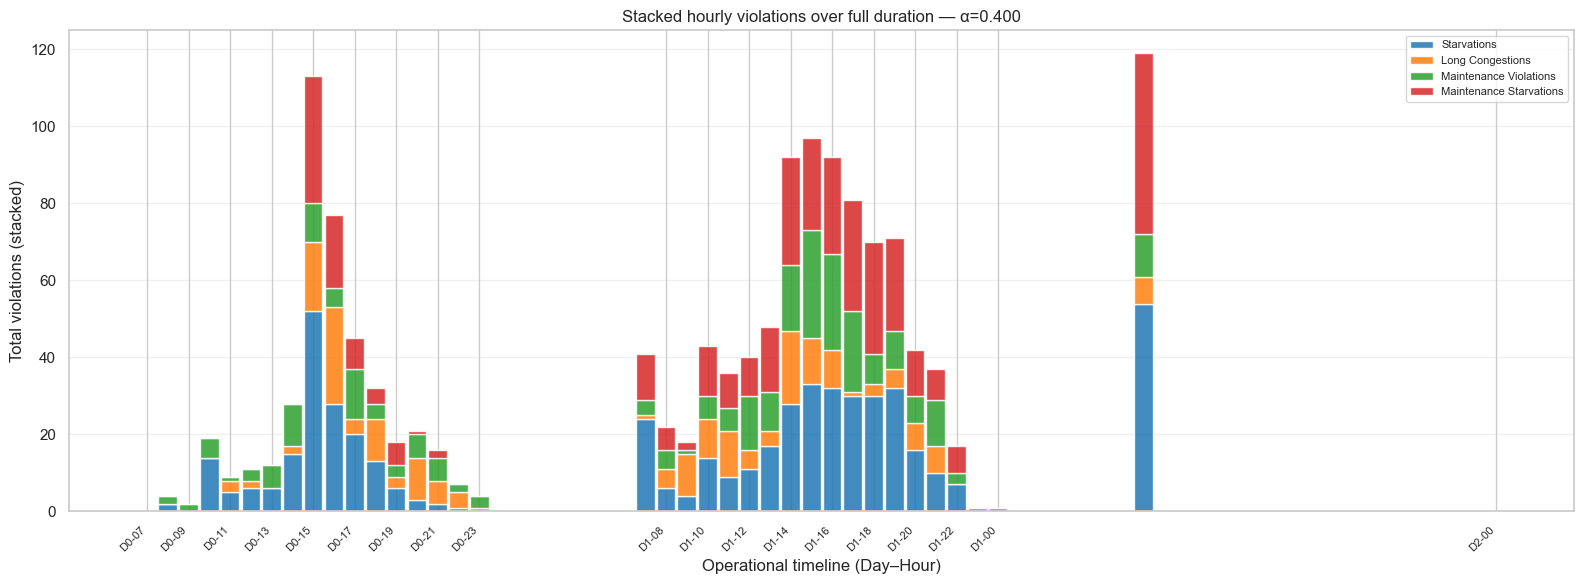

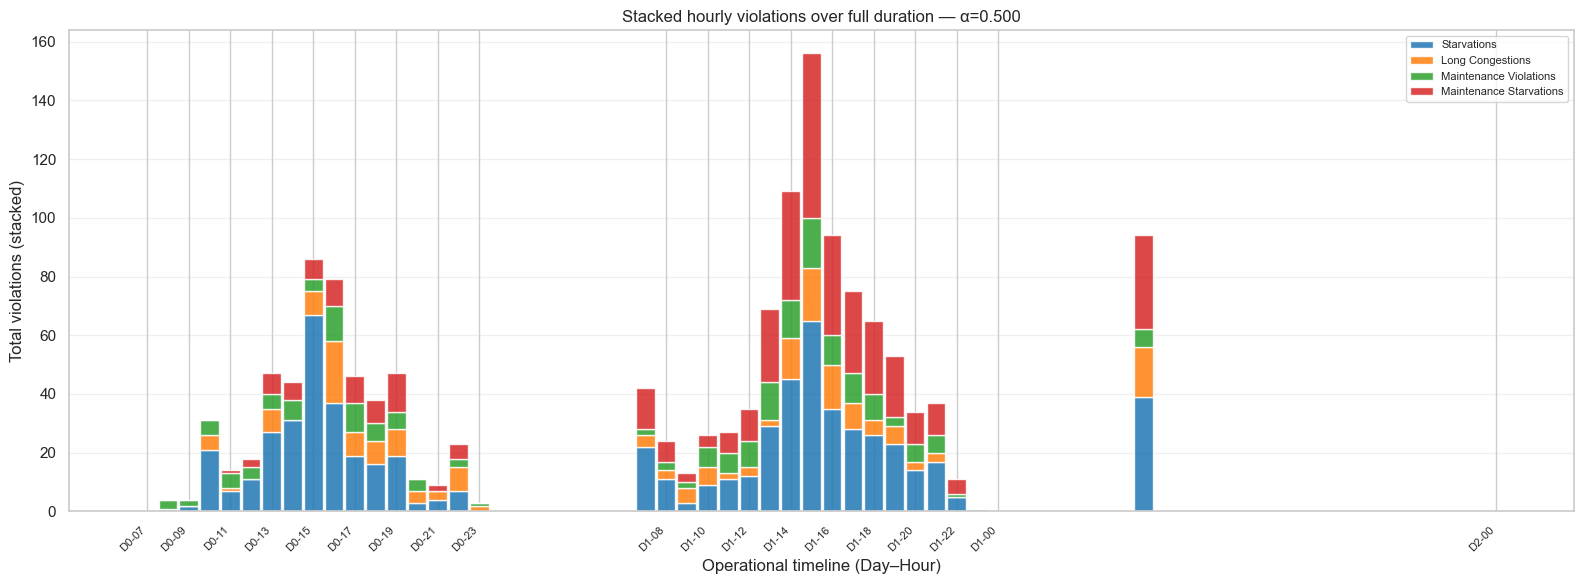

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def hour_in_cycle(h):
    if 7 <= h <= 24:
        return h - 7          # 7→0, 24→17
    elif 1 <= h <= 6:
        return h + 17         # 1→18, 6→23

combined_df["Hour_in_cycle"] = combined_df["Hour"].apply(hour_in_cycle)
combined_df["Cycle_Index"] = combined_df["Day"] * 24 + combined_df["Hour_in_cycle"]

# pretty label:
combined_df["DayHour"] = [
    f"D{int(d)}-{(0 if h==24 else h):02d}"
    for d, h in zip(combined_df.Day, combined_df.Hour)
]


for alpha in unique_alphas:
    df = combined_df[combined_df.alpha == alpha].copy()
    
    df = df.sort_values("Cycle_Index")
    x = df["Cycle_Index"].values
    labels = df["DayHour"].values
    
    bottom = np.zeros(len(df))
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

    plt.figure(figsize=(16,6))

    for i, v in enumerate(violation_cols):
        vals = df[v].values
        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[i % len(colors)],
            label=v,
            width=0.9,
            alpha=0.85,
        )
        bottom += vals

    # x tick labels (subset so not crowded)
    if len(df) <= 18:
        step = 1
    else:
        step = max(1, len(df)//18)

    xticks = x[::step]
    xticklabels = labels[::step]
    
    plt.xticks(xticks, xticklabels, rotation=45, ha="right", fontsize=8)
    plt.ylabel("Total violations (stacked)")
    plt.xlabel("Operational timeline (Day–Hour)")
    plt.title(f"Stacked hourly violations over full duration — α={alpha:.3f}")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# Vehicle Operations Analysis

Plot bike pickups, deliveries, and maintenance time per hour across different alpha values.


In [ ]:
# Vehicle operations data should already be loaded in combined_df
# Check available columns
print("Available columns:")
print(list(combined_df.columns))
print("\nSample data:")
print(combined_df[['Hour', 'alpha', 'Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)']].head(10))


In [ ]:
import matplotlib.pyplot as plt

vehicle_operations = [
    'Bike Pickups',
    'Bike Deliveries',
    'Maintenance Time (minutes)'
]

# Verify all columns exist
available_ops = [op for op in vehicle_operations if op in combined_df.columns]
if len(available_ops) < len(vehicle_operations):
    missing = set(vehicle_operations) - set(available_ops)
    print(f"Warning: Missing columns: {missing}")
    vehicle_operations = available_ops

print(f"Plotting {len(vehicle_operations)} operation types: {vehicle_operations}")

# Unique alpha values
unique_alphas = sorted(combined_df['alpha'].unique())
print(f"\nCreating vehicle operations plots for {len(unique_alphas)} alpha values")

for alpha in unique_alphas:
    # Filter for this alpha – use ALL days/hours
    alpha_data = combined_df[combined_df['alpha'] == alpha].copy()
    if alpha_data.empty:
        print(f"No data for alpha = {alpha}")
        continue

    # Sort chronologically by Day and Time
    alpha_data_sorted = alpha_data.sort_values(['Day', 'Time (minutes)']).reset_index(drop=True)

    # Continuous index for plotting
    alpha_data_sorted['plot_index'] = range(len(alpha_data_sorted))

    # X-axis labels: D0-07, D0-08, ..., D0-23, D0-24, D1-01, ..., etc.
    def format_hour(h):
        # Treat 24 as 00 for nicer labels (midnight)
        return 0 if h == 24 else h

    x_labels = [
        f"D{int(d)}-{format_hour(int(h)):02d}"
        for d, h in zip(alpha_data_sorted['Day'], alpha_data_sorted['Hour'])
    ]

    # ------------------ PLOT ------------------
    # Calculate Total Bike Movement = Pickups + Deliveries
    alpha_data_sorted["Bike Movement"] = (
        alpha_data_sorted.get("Bike Pickups", 0) +
        alpha_data_sorted.get("Bike Deliveries", 0)
    )

    fig, ax1 = plt.subplots(figsize=(14, 8))

    ax1.set_xlabel('Day & Hour', fontsize=12)
    ax1.set_ylabel('Bike Movement (Pickups + Deliveries)', fontsize=12, color='black')

    # One line instead of two
    ax1.plot(
        alpha_data_sorted['plot_index'],
        alpha_data_sorted['Bike Movement'],
        marker='o',
        color='tab:blue',
        label='Bike Movement',
        linewidth=2,
        markersize=5,
        alpha=0.8
    )

    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True, alpha=0.3)

    # Secondary axis: Maintenance time
    ax2 = ax1.twinx()
    ax2.set_ylabel('Maintenance Time (minutes)', fontsize=12, color='tab:red')

    if 'Maintenance Time (minutes)' in alpha_data_sorted.columns:
        ax2.plot(
            alpha_data_sorted['plot_index'],
            alpha_data_sorted['Maintenance Time (minutes)'],
            marker='^',
            color='tab:red',
            label='Maintenance Time',
            linewidth=2,
            markersize=5,
            alpha=0.8,
            linestyle='--'
        )

    ax2.tick_params(axis='y', labelcolor='tab:red')

    # X-ticks: avoid overcrowding
    n_points = len(alpha_data_sorted)
    if n_points <= 16:
        step = 1
    else:
        step = max(1, n_points // 14)   # ~14 labels max

    tick_positions = alpha_data_sorted['plot_index'][::step]
    tick_labels = [x_labels[i] for i in range(0, n_points, step)]

    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

    # Title
    fig.suptitle(
        f'Vehicle Operations by Day & Hour - Alpha = {alpha:.3f}',
        fontsize=14, fontweight='bold'
    )

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

    plt.tight_layout()

    # Save
    output_dir = results_dir_root / 'vehicle_operations_plots'
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / f'vehicle_ops_day_hour_alpha_{alpha:.3f}.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"Saved: {output_file}")

    plt.show()
    plt.close()

print("\nAll vehicle operations plots created successfully!")


In [ ]:
import matplotlib.pyplot as plt

# Make sure Bike Movement exists once in the combined_df
if 'Bike Movement' not in combined_df.columns:
    combined_df['Bike Movement'] = (
        combined_df.get('Bike Pickups', 0).fillna(0) +
        combined_df.get('Bike Deliveries', 0).fillna(0)
    )

# Unique alpha values
unique_alphas = sorted(combined_df['alpha'].unique())
n_alphas = len(unique_alphas)

# Grid layout
n_cols = 3
n_rows = (n_alphas + n_cols - 1) // n_cols

# ------------------------------------------------------------------
# Global min/max for equal y-axis scaling (use ALL days/hours)
# ------------------------------------------------------------------
data_for_range = combined_df.copy()

# Bike movement range (left axis)
if 'Bike Movement' in data_for_range.columns:
    bike_ops_min = data_for_range['Bike Movement'].min()
    bike_ops_max = data_for_range['Bike Movement'].max()
else:
    bike_ops_min, bike_ops_max = 0, 1

bike_ops_range = bike_ops_max - bike_ops_min
if bike_ops_range > 0:
    bike_ops_min = max(0, bike_ops_min - bike_ops_range * 0.05)
    bike_ops_max = bike_ops_max + bike_ops_range * 0.05
else:
    bike_ops_min = 0
    bike_ops_max = max(1, bike_ops_max * 1.1)

# Maintenance time range (right axis)
if 'Maintenance Time (minutes)' in data_for_range.columns:
    maint_min = data_for_range['Maintenance Time (minutes)'].min()
    maint_max = data_for_range['Maintenance Time (minutes)'].max()
    maint_range = maint_max - maint_min

    if maint_range > 0:
        maint_min = max(0, maint_min - maint_range * 0.1)
        maint_max = maint_max + maint_range * 0.1
    else:
        if maint_max == 0:
            maint_min, maint_max = 0, 1
        else:
            maint_min = max(0, maint_max * 0.9)
            maint_max = maint_max * 1.1
else:
    maint_min, maint_max = 0, 10

# ------------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Vehicle Operations Across All Alpha Values', fontsize=16, fontweight='bold')

if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

def format_hour(h):
    # Treat 24 as 00 for nicer labels
    return 0 if h == 24 else h

for idx, alpha in enumerate(unique_alphas):
    ax1 = axes[idx]

    # Filter data for this alpha (all days/hours)
    alpha_data = combined_df[combined_df['alpha'] == alpha].copy()
    if alpha_data.empty:
        ax1.set_title(f'Alpha = {alpha:.3f}\n(no data)')
        ax1.axis('off')
        continue

    # Sort by Day and Time
    alpha_data_sorted = alpha_data.sort_values(['Day', 'Time (minutes)']).reset_index(drop=True)

    # Continuous index for plotting
    alpha_data_sorted['Plot_Index'] = range(len(alpha_data_sorted))

    # X-axis labels: D0-07, D0-08, ..., D1-00, etc.
    x_labels = [
        f"D{int(d)}-{format_hour(int(h)):02d}"
        for d, h in zip(alpha_data_sorted['Day'], alpha_data_sorted['Hour'])
    ]

    # ---------- Left axis: Bike Movement ----------
    ax1.plot(
        alpha_data_sorted['Plot_Index'],
        alpha_data_sorted['Bike Movement'],
        marker='o',
        color='tab:blue',
        label='Bike Movement',
        linewidth=1.5,
        markersize=4,
        alpha=0.8
    )
    ax1.set_ylim(bike_ops_min, bike_ops_max)
    ax1.set_ylabel('Bike Movement (Pickups + Deliveries)', fontsize=9, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True, alpha=0.3)

    # ---------- Right axis: Maintenance Time ----------
    ax2 = ax1.twinx()
    if 'Maintenance Time (minutes)' in alpha_data_sorted.columns:
        ax2.plot(
            alpha_data_sorted['Plot_Index'],
            alpha_data_sorted['Maintenance Time (minutes)'],
            marker='^',
            color='tab:red',
            label='Maint. (min)',
            linewidth=1.5,
            markersize=4,
            alpha=0.8,
            linestyle='--'
        )

    ax2.set_ylim(maint_min, maint_max)
    ax2.set_ylabel('Maintenance Time (min)', fontsize=9, color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Title & x-axis
    ax1.set_title(f'Alpha = {alpha:.3f}', fontsize=11)
    ax1.set_xlabel('Day & Hour', fontsize=9)

    # X-ticks: avoid overcrowding
    n_points = len(alpha_data_sorted)
    if n_points <= 16:
        step = 1
    else:
        step = max(1, n_points // 12)   # ~12 ticks per subplot

    tick_positions = alpha_data_sorted['Plot_Index'][::step]
    tick_labels = [x_labels[i] for i in range(0, n_points, step)]

    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=7)

# Hide unused subplots (if any)
for idx in range(len(unique_alphas), len(axes)):
    axes[idx].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the combined plot
output_dir = results_dir_root / 'vehicle_operations_plots'
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / 'all_alphas_vehicle_operations.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Saved combined plot: {output_file}")

plt.show()


## hourly curves for all alpha

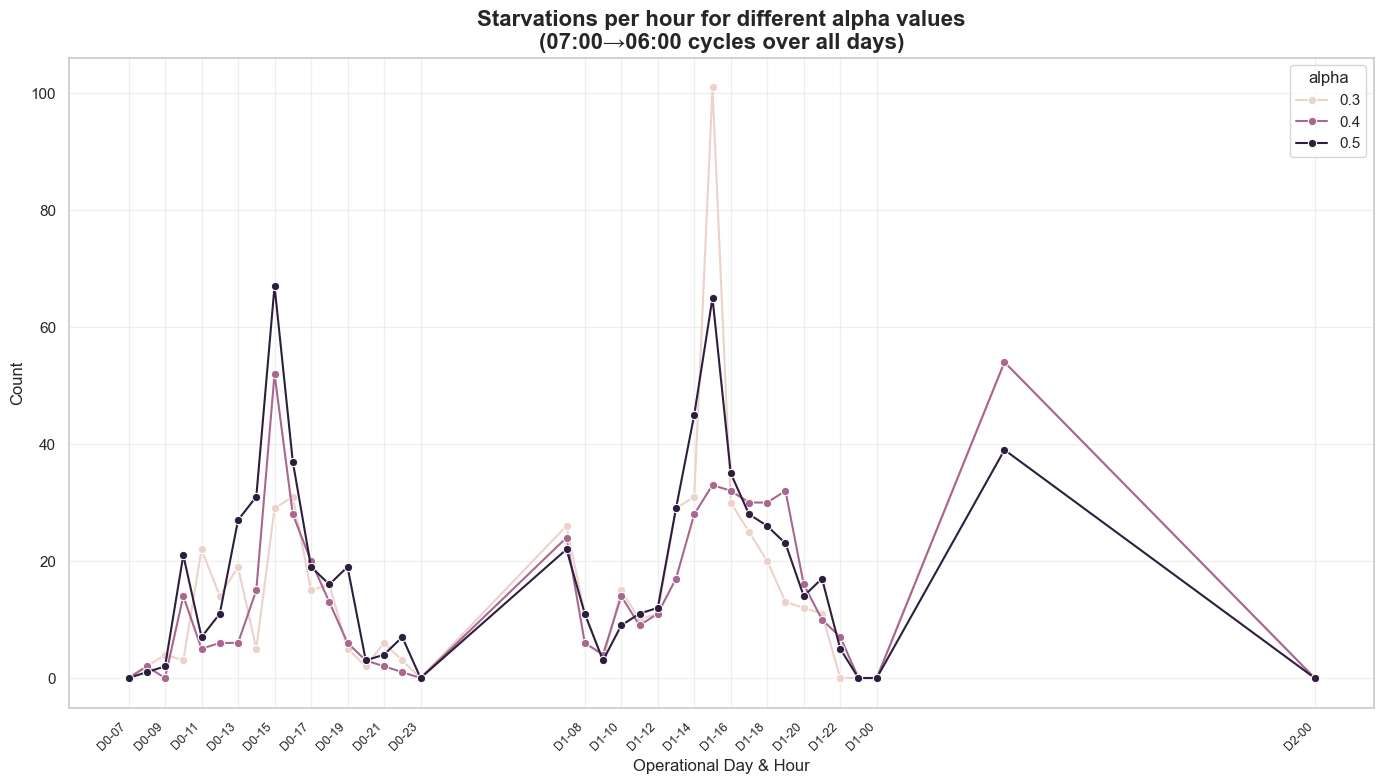

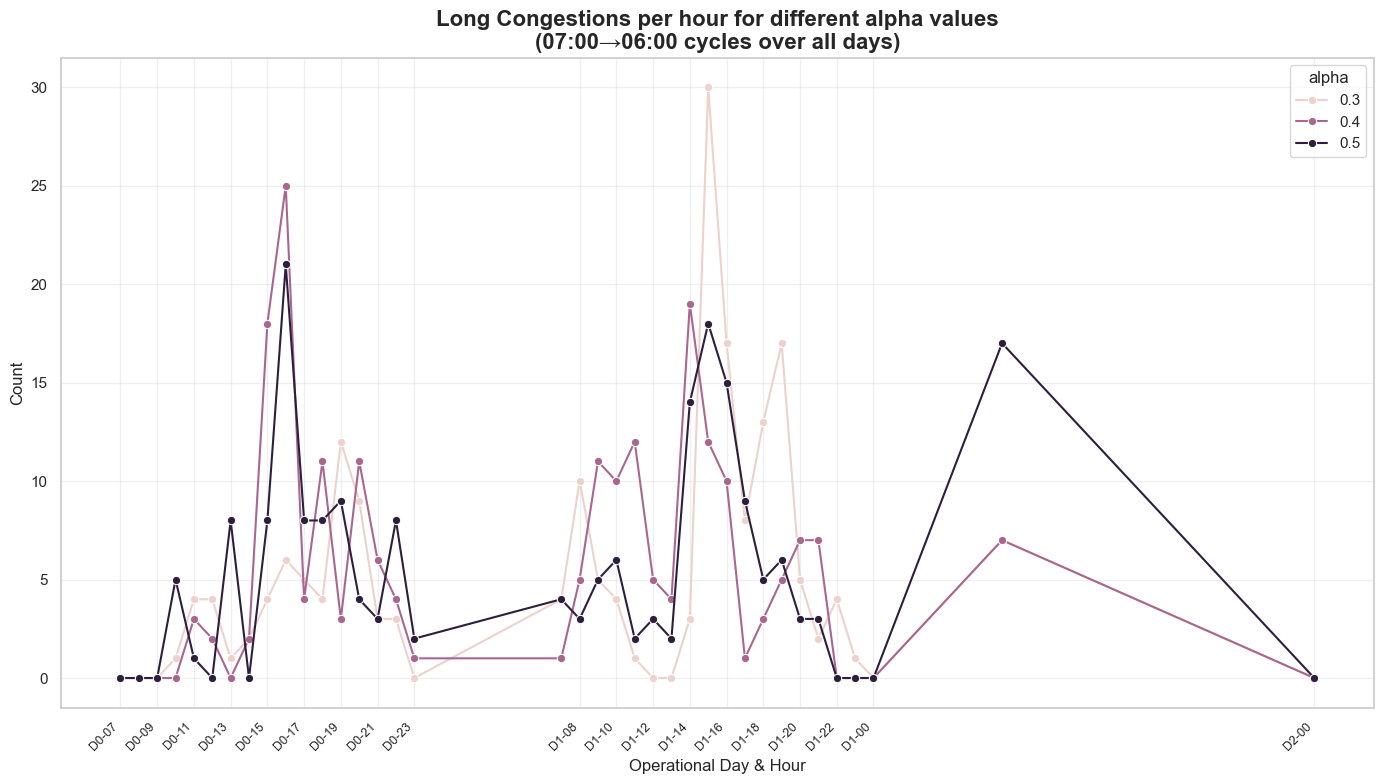

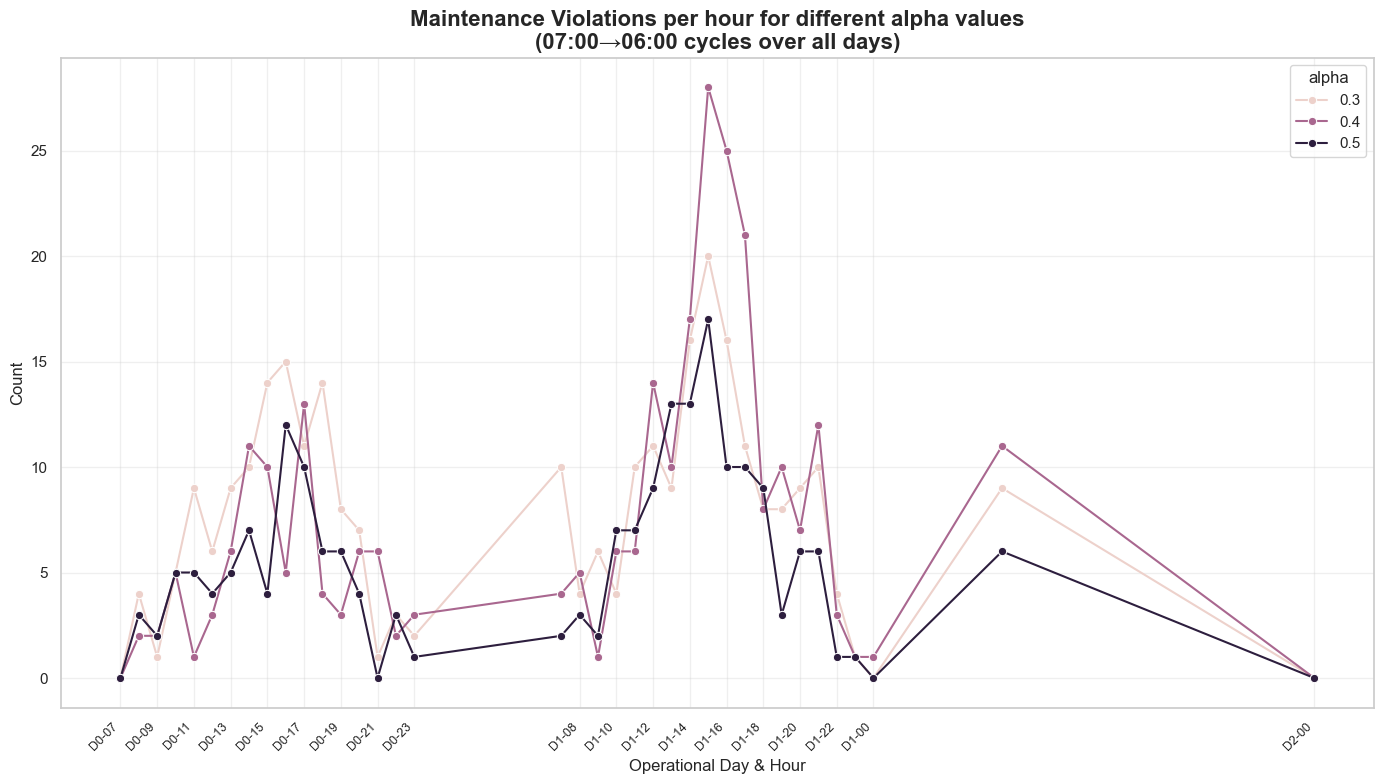

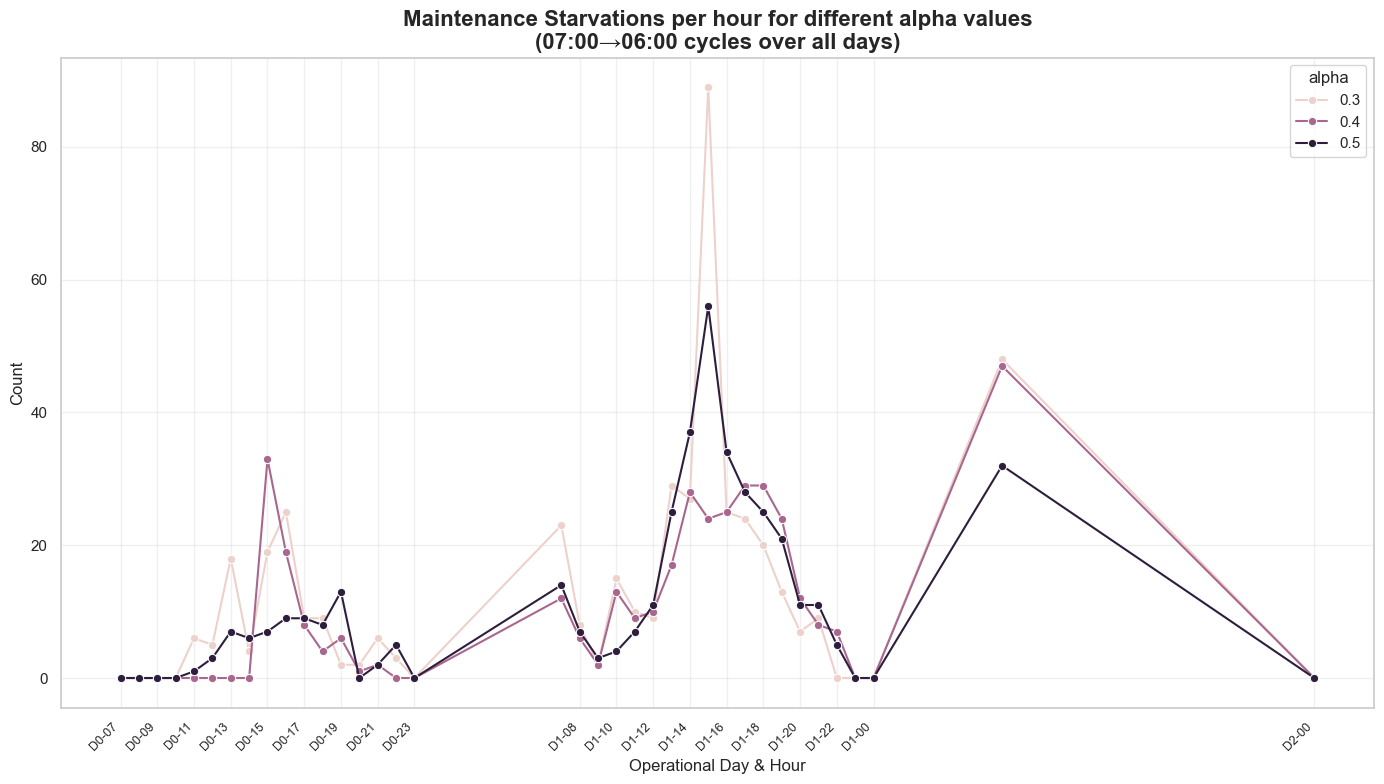

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Map Hour into a 0–23 index in the order 7–24, 1–6
def hour_in_cycle(h):
    if 7 <= h <= 24:
        return h - 7          # 7 -> 0, 24 -> 17
    elif 1 <= h <= 6:
        return h + 17         # 1 -> 18, 6 -> 23
    else:
        return np.nan         # in case of weird hours

combined_df["Hour_in_cycle"] = combined_df["Hour"].apply(hour_in_cycle)

# 2) Serial index over the whole horizon: 07–06 cycles repeated by Day
combined_df["Cycle_Index"] = combined_df["Day"] * 24 + combined_df["Hour_in_cycle"]

# 3) Nice Day–Hour label for ticks: D0-07, D0-08, ..., D1-00, ...
def format_hour(h):
    # optional: turn 24 into 00 for display
    return 0 if h == 24 else h

combined_df["DayHourLabel"] = [
    f"D{int(d)}-{format_hour(int(h)):02d}"
    for d, h in zip(combined_df["Day"], combined_df["Hour"])
]

# Sort for safety
combined_df = combined_df.sort_values(["alpha", "Cycle_Index"])

# 4) Plot each violation type over the full duration, one line per alpha
for v in violation_cols:
    plt.figure(figsize=(14, 8))

    sns.lineplot(
        data=combined_df,
        x="Cycle_Index",
        y=v,
        hue="alpha",
        marker="o"
    )

    # Build x-ticks with readable labels (don’t show all, avoid clutter)
    # Use unique Cycle_Index values in order
    idxs = combined_df["Cycle_Index"].dropna().unique()
    idxs = np.sort(idxs)

    n_points = len(idxs)
    if n_points <= 16:
        step = 1
    else:
        step = max(1, n_points // 14)   # ~14 labels

    tick_positions = idxs[::step]

    # For each tick position, grab one matching DayHourLabel
    label_map = (
        combined_df.drop_duplicates("Cycle_Index")
                   .set_index("Cycle_Index")["DayHourLabel"]
    )
    tick_labels = [label_map[pos] for pos in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=9)

    plt.title(f"{v} per hour for different alpha values\n(07:00→06:00 cycles over all days)",
              fontsize=16, fontweight="bold")
    plt.xlabel("Operational Day & Hour")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.legend(title="alpha")
    plt.tight_layout()
    plt.show()


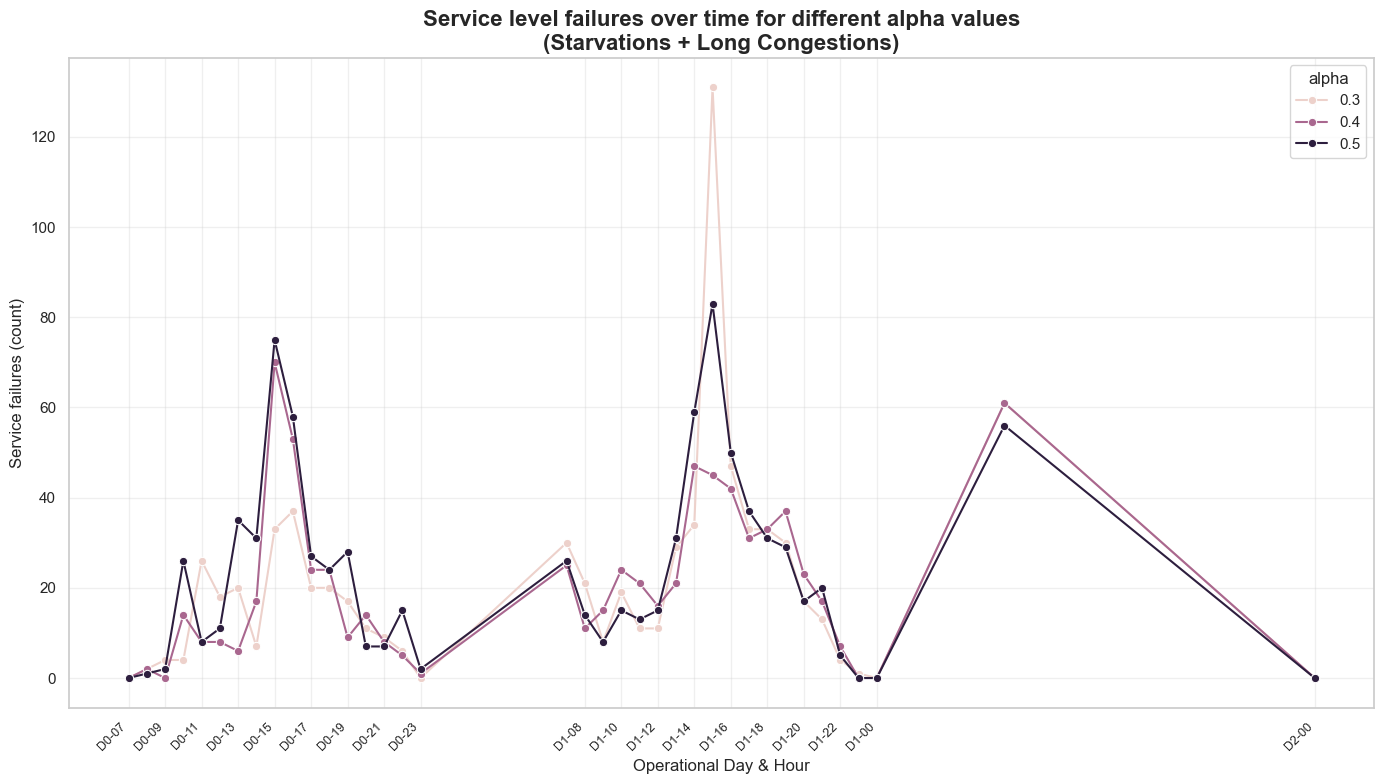

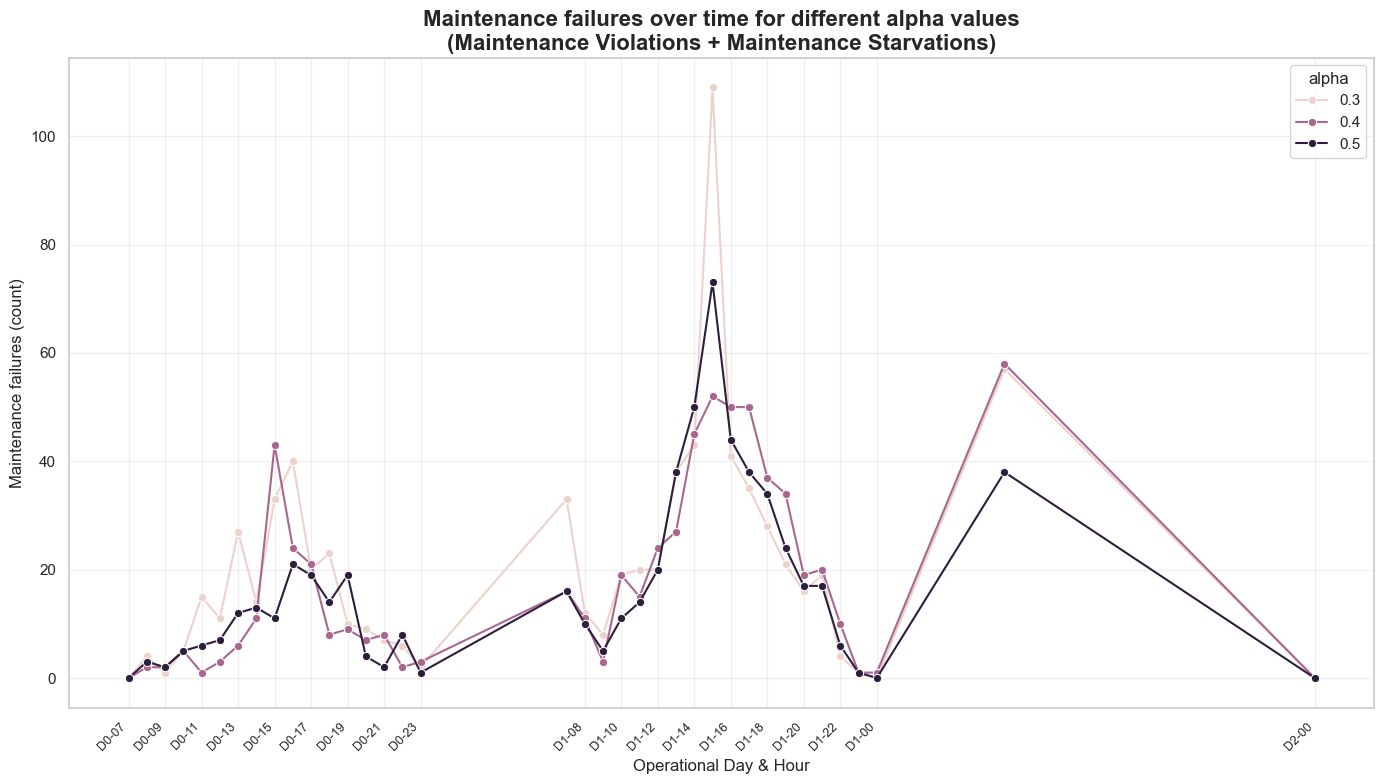

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Map Hour into a 0–23 index in the order 7–24, 1–6
def hour_in_cycle(h):
    if 7 <= h <= 24:
        return h - 7          # 7 -> 0, 24 -> 17
    elif 1 <= h <= 6:
        return h + 17         # 1 -> 18, 6 -> 23
    else:
        return np.nan         # in case of weird hours

combined_df["Hour_in_cycle"] = combined_df["Hour"].apply(hour_in_cycle)

# 2) Serial index over the whole horizon: 07–06 cycles repeated by Day
combined_df["Cycle_Index"] = combined_df["Day"] * 24 + combined_df["Hour_in_cycle"]

# 3) Nice Day–Hour label for ticks: D0-07, D0-08, ..., D1-00, ...
def format_hour(h):
    return 0 if h == 24 else h

combined_df["DayHourLabel"] = [
    f"D{int(d)}-{format_hour(int(h)):02d}"
    for d, h in zip(combined_df["Day"], combined_df["Hour"])
]

# 4) Aggregated categories
combined_df["Service_Failures"] = (
    combined_df["Starvations"].fillna(0) +
    combined_df["Long Congestions"].fillna(0)
    # If you want to include Short Congestions too, add:
    # + combined_df["Short Congestions"].fillna(0)
)

combined_df["Maintenance_Failures"] = (
    combined_df["Maintenance Violations"].fillna(0) +
    combined_df["Maintenance Starvations"].fillna(0)
)

# Sort for safety
combined_df = combined_df.sort_values(["alpha", "Cycle_Index"])

# Precompute label map for x-ticks
label_map = (
    combined_df.drop_duplicates("Cycle_Index")
               .set_index("Cycle_Index")["DayHourLabel"]
)

# Helper to set nice x-ticks
def set_time_xticks(ax, df_for_ticks):
    idxs = df_for_ticks["Cycle_Index"].dropna().unique()
    idxs = np.sort(idxs)

    n_points = len(idxs)
    if n_points <= 16:
        step = 1
    else:
        step = max(1, n_points // 14)   # ~14 labels

    tick_positions = idxs[::step]
    tick_labels = [label_map[pos] for pos in tick_positions]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)

# -------------------------------------------------------------------
# Plot 1: Service level failures vs time (one line per alpha)
# -------------------------------------------------------------------
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=combined_df,
    x="Cycle_Index",
    y="Service_Failures",
    hue="alpha",
    marker="o"
)

set_time_xticks(plt.gca(), combined_df)

plt.title(
    "Service level failures over time for different alpha values\n"
    "(Starvations + Long Congestions)",
    fontsize=16, fontweight="bold"
)
plt.xlabel("Operational Day & Hour")
plt.ylabel("Service failures (count)")
plt.grid(True, alpha=0.3)
plt.legend(title="alpha")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot 2: Maintenance failures vs time (one line per alpha)
# -------------------------------------------------------------------
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=combined_df,
    x="Cycle_Index",
    y="Maintenance_Failures",
    hue="alpha",
    marker="o"
)

set_time_xticks(plt.gca(), combined_df)

plt.title(
    "Maintenance failures over time for different alpha values\n"
    "(Maintenance Violations + Maintenance Starvations)",
    fontsize=16, fontweight="bold"
)
plt.xlabel("Operational Day & Hour")
plt.ylabel("Maintenance failures (count)")
plt.grid(True, alpha=0.3)
plt.legend(title="alpha")
plt.tight_layout()
plt.show()
